# FlexOn — Experiments

This notebook is the **benchmark and analysis layer** of the project.

It runs the six core execution modes against the frozen `flexon_online` runtime:

| Case | Resource selection | Adaptive level | Recovery |
|---|---|---:|---:|
| Fixed CPU | CPU | No | No |
| Fixed CUDA | CUDA | No | No |
| Dynamic | Auto | No | No |
| Dynamic + Adaptive | Auto | Yes | No |
| Dynamic + Recovery | Auto | No | Yes |
| Dynamic + Adaptive + Recovery | Auto | Yes | Yes |

This notebook deliberately has **no contention API**. If contention is desired, start it independently from `contention_generator.ipynb`; the same benchmark code then measures the stressed environment.

## Experimental principle

The separation is intentional:

- `experiments.contention` controls the machine environment.
- `experiments.runner` invokes and parses FlexOn.
- `experiments.measurements` computes latency statistics.
- `experiments.analysis` builds comparable dataframes.
- `experiments.plotting` produces research figures.

Therefore the six cases below are identical with or without contention.

In [2]:
from pathlib import Path
import sys
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "experiments").is_dir():
    PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from experiments.config import ExperimentConfig, RunConfig
from experiments.runner import run_online
from experiments.measurements import measure_run
from experiments.analysis import (
    ExperimentRecord,
    run_summary_dataframe,
    latency_samples_dataframe,
    summarize_latency,
    compare_latency,
    runtime_diagnostics_dataframe,
)
from experiments.plotting import (
    plot_latency_comparison,
    plot_tail_latency,
    plot_latency_distribution,
    plot_latency_percentiles,
    plot_resource_execution_breakdown,
    plot_level_changes,
)

print(f"Project root: {PROJECT_ROOT}")


Project root: /home/aditya/Coding_23CSB0B30/Personal-Projects/FlexOn


## Benchmark configuration

Start with a moderate benchmark while validating the pipeline. Once the experiment is stable, increase repetitions if the contention environment is noisy.

The runtime's unconditional `[scheduler] iteration measured_ms=...` record is the authoritative end-to-end iteration latency. Warmups are removed positionally.

In [3]:
EXPERIMENT = ExperimentConfig(
    warmup_iterations=10,
    measured_iterations=50,
    repetitions=5,
    timeout_seconds=300,
)

ARTIFACT = PROJECT_ROOT / "artifacts" / "resnet18"
ONLINE_BINARY = PROJECT_ROOT / "apps" / "flexon_online"
SCHEDULER_CONFIG = PROJECT_ROOT / "config" / "scheduler.yaml"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Set this manually for result bookkeeping. It does NOT start or control contention.
# Examples: "no_contention", "cpu-25gpu-25", "cpu50gpu50".
ENVIRONMENT_LABEL = "no_contention"

# Protect FlexOn scheduler/control logic while keeping inference at normal CPU
# scheduling priority. Requires the one-time setup of the privileged scheduler helper.
PRIORITY_ISOLATION = True
(RESULTS_DIR / ENVIRONMENT_LABEL).mkdir(parents=True, exist_ok=True)

if not ONLINE_BINARY.exists():
    raise FileNotFoundError(f"Online binary not found: {ONLINE_BINARY}")
if not ARTIFACT.exists():
    raise FileNotFoundError(f"Artifact not found: {ARTIFACT}")

print("artifact:", ARTIFACT)
print("binary:", ONLINE_BINARY)
print("warmup:", EXPERIMENT.warmup_iterations)
print("measured:", EXPERIMENT.measured_iterations)
print("repetitions:", EXPERIMENT.repetitions)

artifact: /home/aditya/Coding_23CSB0B30/Personal-Projects/FlexOn/artifacts/resnet18
binary: /home/aditya/Coding_23CSB0B30/Personal-Projects/FlexOn/apps/flexon_online
warmup: 10
measured: 50
repetitions: 5


### Priority-isolated execution

When `PRIORITY_ISOLATION` is enabled, the experiment runner launches `flexon_online` through `apps/flexon_online`. The launcher starts `flexon_online` normally, waits for CUDA/ONNX Runtime initialization to complete, then promotes the already-running control thread to `SCHED_FIFO` at the maximum Linux real-time priority. The runtime demotes actual inference execution to normal priority.


## Define the six benchmark cases

These are the only execution-policy dimensions varied in the core experiment matrix. Contention is an external environment and is therefore not encoded here.

In [4]:
CASES = {
    "fixed_cpu": RunConfig(
        artifact=ARTIFACT,
        iterations=EXPERIMENT.warmup_iterations + EXPERIMENT.measured_iterations,
        level=0,
        resource="cpu",
        scheduler_config=SCHEDULER_CONFIG,
    ),

    "fixed_cuda": RunConfig(
        artifact=ARTIFACT,
        iterations=EXPERIMENT.warmup_iterations + EXPERIMENT.measured_iterations,
        level=0,
        resource="cuda",
        scheduler_config=SCHEDULER_CONFIG,
    ),

    "dynamic": RunConfig(
        priority_isolation=PRIORITY_ISOLATION,
        artifact=ARTIFACT,
        iterations=EXPERIMENT.warmup_iterations + EXPERIMENT.measured_iterations,
        resource="auto",
        scheduler_config=SCHEDULER_CONFIG,
    ),

    "dynamic_adaptive": RunConfig(
        priority_isolation=PRIORITY_ISOLATION,
        artifact=ARTIFACT,
        iterations=EXPERIMENT.warmup_iterations + EXPERIMENT.measured_iterations,
        resource="auto",
        adaptive_level=True,
        scheduler_config=SCHEDULER_CONFIG,
    ),

    "dynamic_recovery": RunConfig(
        priority_isolation=PRIORITY_ISOLATION,
        artifact=ARTIFACT,
        iterations=EXPERIMENT.warmup_iterations + EXPERIMENT.measured_iterations,
        resource="auto",
        recovery=True,
        scheduler_config=SCHEDULER_CONFIG,
    ),

    "dynamic_adaptive_recovery": RunConfig(
        priority_isolation=PRIORITY_ISOLATION,
        artifact=ARTIFACT,
        iterations=EXPERIMENT.warmup_iterations + EXPERIMENT.measured_iterations,
        resource="auto",
        adaptive_level=True,
        recovery=True,
        scheduler_config=SCHEDULER_CONFIG,
    ),
}

for name, config in CASES.items():
    print(name, "->", " ".join(config.command(ONLINE_BINARY)))

fixed_cpu -> /home/aditya/Coding_23CSB0B30/Personal-Projects/FlexOn/apps/flexon_online --artifact /home/aditya/Coding_23CSB0B30/Personal-Projects/FlexOn/artifacts/resnet18 --iterations 60 --resource cpu --scheduler-config /home/aditya/Coding_23CSB0B30/Personal-Projects/FlexOn/config/scheduler.yaml --level 0
fixed_cuda -> /home/aditya/Coding_23CSB0B30/Personal-Projects/FlexOn/apps/flexon_online --artifact /home/aditya/Coding_23CSB0B30/Personal-Projects/FlexOn/artifacts/resnet18 --iterations 60 --resource cuda --scheduler-config /home/aditya/Coding_23CSB0B30/Personal-Projects/FlexOn/config/scheduler.yaml --level 0
dynamic -> /home/aditya/Coding_23CSB0B30/Personal-Projects/FlexOn/apps/flexon_online --artifact /home/aditya/Coding_23CSB0B30/Personal-Projects/FlexOn/artifacts/resnet18 --iterations 60 --resource auto --scheduler-config /home/aditya/Coding_23CSB0B30/Personal-Projects/FlexOn/config/scheduler.yaml --priority-isolation
dynamic_adaptive -> /home/aditya/Coding_23CSB0B30/Personal-Pr

## Experiment runner

Each repetition is one independent invocation of `flexon_online`. The parser remains isolated from the subprocess call, and measurement uses the authoritative iteration-level timing.

In [5]:
def run_case(name: str, config: RunConfig) -> list[ExperimentRecord]:
    records = []
    for repetition in range(1, EXPERIMENT.repetitions + 1):
        run = run_online(
            config,
            binary=ONLINE_BINARY,
            timeout=EXPERIMENT.timeout_seconds,
            cwd=PROJECT_ROOT,
        )
        if not run.success:
            raise RuntimeError(
                f"{name} repetition {repetition} failed: {run.error or run.stderr}"
            )

        measurements = measure_run(
            run,
            warmup_iterations=EXPERIMENT.warmup_iterations,
        )
        records.append(
            ExperimentRecord(
                experiment=name,
                repetition=repetition,
                measurements=measurements,
                metadata={
                    "environment": ENVIRONMENT_LABEL,
                    "artifact": str(ARTIFACT),
                    "resource": config.resource,
                    "adaptive_level": config.adaptive_level,
                    "recovery": config.recovery,
                    "priority_isolation": config.priority_isolation,
                },
            )
        )
        print(
            f"{name}: repetition {repetition}/{EXPERIMENT.repetitions} "
            f"mean={measurements.latency.mean_ms:.3f} ms "
            f"p95={measurements.latency.p95_ms:.3f} ms"
        )
    return records


def run_all_cases():
    all_records = []
    for name, config in CASES.items():
        all_records.extend(run_case(name, config))
        print("-" * 100)
    return all_records

## Run the six cases

> **If using contention:** start the desired contention session in `contention_generator.ipynb` before executing this cell.

> **Without contention:** simply execute this cell with the contention session stopped.

In [6]:
records = run_all_cases()
print(f"Collected {len(records)} measured repetitions")

fixed_cpu: repetition 1/5 mean=37.450 ms p95=48.214 ms
fixed_cpu: repetition 2/5 mean=35.415 ms p95=41.412 ms
fixed_cpu: repetition 3/5 mean=35.335 ms p95=42.895 ms
fixed_cpu: repetition 4/5 mean=34.769 ms p95=41.510 ms
fixed_cpu: repetition 5/5 mean=35.418 ms p95=42.239 ms
----------------------------------------------------------------------------------------------------
fixed_cuda: repetition 1/5 mean=5.809 ms p95=7.012 ms
fixed_cuda: repetition 2/5 mean=6.017 ms p95=8.289 ms
fixed_cuda: repetition 3/5 mean=5.740 ms p95=7.274 ms
fixed_cuda: repetition 4/5 mean=5.864 ms p95=7.230 ms
fixed_cuda: repetition 5/5 mean=6.811 ms p95=11.714 ms
----------------------------------------------------------------------------------------------------
dynamic: repetition 1/5 mean=37.947 ms p95=49.704 ms
dynamic: repetition 2/5 mean=37.876 ms p95=49.653 ms
dynamic: repetition 3/5 mean=36.317 ms p95=43.377 ms
dynamic: repetition 4/5 mean=36.672 ms p95=43.944 ms
dynamic: repetition 5/5 mean=35.278 ms p

## Repetition-level summary

In [8]:
summary = run_summary_dataframe(records)
summary.loc[:, :].round(3)

,experiment,repetition,count,mean_ms,median_ms,p90_ms,p95_ms,p99_ms,min_ms,max_ms,std_ms,environment,artifact,resource,adaptive_level,recovery,priority_isolation
0,fixed_cpu,1,50,22.054,21.887,22.276,22.812,24.460,21.706,25.901,0.620,no_contention,/home/aditya/Coding_23CSB0B30/Personal-Project...,cpu,False,False,False
1,fixed_cpu,2,50,22.600,22.315,23.533,24.269,26.874,21.745,27.222,1.077,no_contention,/home/aditya/Coding_23CSB0B30/Personal-Project...,cpu,False,False,False
2,fixed_cpu,3,50,22.428,22.183,23.404,24.337,26.106,21.803,26.602,0.936,no_contention,/home/aditya/Coding_23CSB0B30/Personal-Project...,cpu,False,False,False
3,fixed_cpu,4,50,22.573,22.245,23.012,25.233,26.195,21.802,27.062,1.022,no_contention,/home/aditya/Coding_23CSB0B30/Personal-Project...,cpu,False,False,False
4,fixed_cpu,5,50,22.380,22.030,22.969,23.847,26.223,21.854,26.554,0.910,no_contention,/home/aditya/Coding_23CSB0B30/Personal-Project...,cpu,False,False,False
5,fixed_cuda,1,50,1.200,1.162,1.342,1.525,1.852,1.003,2.042,0.177,no_contention,/home/aditya/Coding_23CSB0B30/Personal-Project...,cuda,False,False,False
6,fixed_cuda,2,50,2.522,1.292,5.563,5.597,5.943,1.055,6.140,2.015,no_contention,/home/aditya/Coding_23CSB0B30/Personal-Project...,cuda,False,False,False
7,fixed_cuda,3,50,3.211,1.723,5.545,5.668,5.814,1.034,5.818,2.128,no_contention,/home/aditya/Coding_23CSB0B30/Personal-Project...,cuda,False,False,False
8,fixed_cuda,4,50,5.498,5.513,5.707,5.771,6.107,3.344,6.385,0.365,no_contention,/home/aditya/Coding_23CSB0B30/Personal-Project...,cuda,False,False,False
9,fixed_cuda,5,50,3.798,5.424,5.708,5.816,7.538,1.054,8.841,2.278,no_contention,/home/aditya/Coding_23CSB0B30/Personal-Project...,cuda,False,False,False


## Pooled latency summary

This pools all measured iteration samples belonging to each condition. Median and tail latency are retained alongside the mean.

In [9]:
pooled_summary = summarize_latency(records, by=("experiment",))
pooled_summary.round(3)

,experiment,count,mean_ms,median_ms,p90_ms,p95_ms,p99_ms,min_ms,max_ms,std_ms
0,fixed_cpu,250,22.407,22.086,23.228,24.394,26.579,21.706,27.222,0.940
1,fixed_cuda,250,3.246,1.546,5.637,5.729,6.161,1.003,8.841,2.184
2,dynamic,250,1.608,1.316,1.752,5.297,5.833,1.099,6.178,1.004
3,dynamic_adaptive,250,3.089,1.402,5.784,5.877,23.371,1.033,28.122,3.759
4,dynamic_recovery,250,1.943,1.456,4.066,4.333,5.482,1.221,6.308,1.091
5,dynamic_adaptive_recovery,250,1.412,1.204,1.516,1.761,6.437,1.060,8.071,0.903


## Resource/recovery diagnostics

These metrics are useful for confirming that the feature modes actually exercised the intended runtime paths.

In [10]:
diagnostics_df = runtime_diagnostics_dataframe(records)
diagnostics_df.loc[:,:].round(3)

,experiment,repetition,cpu_segment_executions,cuda_segment_executions,total_segment_executions,avg_segments_per_iteration,cpu_execution_pct,cuda_execution_pct,adaptive_decisions,level_changes,...,recovery_trigger_rate_pct,recovery_primary_wins,recovery_alternative_wins,recovery_unresolved,environment,artifact,resource,adaptive_level,recovery,priority_isolation
0,fixed_cpu,1,50,0,50,1.00,100.0,0.0,0,0,...,0.0,0,0,0,no_contention,/home/aditya/Coding_23CSB0B30/Personal-Project...,cpu,False,False,False
1,fixed_cpu,2,50,0,50,1.00,100.0,0.0,0,0,...,0.0,0,0,0,no_contention,/home/aditya/Coding_23CSB0B30/Personal-Project...,cpu,False,False,False
2,fixed_cpu,3,50,0,50,1.00,100.0,0.0,0,0,...,0.0,0,0,0,no_contention,/home/aditya/Coding_23CSB0B30/Personal-Project...,cpu,False,False,False
3,fixed_cpu,4,50,0,50,1.00,100.0,0.0,0,0,...,0.0,0,0,0,no_contention,/home/aditya/Coding_23CSB0B30/Personal-Project...,cpu,False,False,False
4,fixed_cpu,5,50,0,50,1.00,100.0,0.0,0,0,...,0.0,0,0,0,no_contention,/home/aditya/Coding_23CSB0B30/Personal-Project...,cpu,False,False,False
5,fixed_cuda,1,0,50,50,1.00,0.0,100.0,0,0,...,0.0,0,0,0,no_contention,/home/aditya/Coding_23CSB0B30/Personal-Project...,cuda,False,False,False
6,fixed_cuda,2,0,50,50,1.00,0.0,100.0,0,0,...,0.0,0,0,0,no_contention,/home/aditya/Coding_23CSB0B30/Personal-Project...,cuda,False,False,False
7,fixed_cuda,3,0,50,50,1.00,0.0,100.0,0,0,...,0.0,0,0,0,no_contention,/home/aditya/Coding_23CSB0B30/Personal-Project...,cuda,False,False,False
8,fixed_cuda,4,0,50,50,1.00,0.0,100.0,0,0,...,0.0,0,0,0,no_contention,/home/aditya/Coding_23CSB0B30/Personal-Project...,cuda,False,False,False
9,fixed_cuda,5,0,50,50,1.00,0.0,100.0,0,0,...,0.0,0,0,0,no_contention,/home/aditya/Coding_23CSB0B30/Personal-Project...,cuda,False,False,False


## Compare against fixed CPU baseline

In [11]:
comparison = compare_latency(
    pooled_summary,
    baseline="fixed_cpu",
)
comparison[[
    "experiment", "mean_ms", "p95_ms", "p99_ms",
    "speedup", "latency_reduction_pct", "p95_reduction_pct", "p99_reduction_pct",
]].round(3)


,experiment,mean_ms,p95_ms,p99_ms,speedup,latency_reduction_pct,p95_reduction_pct,p99_reduction_pct
0,fixed_cpu,22.407,24.394,26.579,1.000,0.000,0.000,0.000
1,fixed_cuda,3.246,5.729,6.161,6.903,85.514,76.513,76.818
2,dynamic,1.608,5.297,5.833,13.937,92.825,78.283,78.053
3,dynamic_adaptive,3.089,5.877,23.371,7.253,86.212,75.909,12.069
4,dynamic_recovery,1.943,4.333,5.482,11.534,91.330,82.235,79.376
5,dynamic_adaptive_recovery,1.412,1.761,6.437,15.864,93.697,92.780,75.780


## Compare against fixed GPU baseline

In [12]:
comparison = compare_latency(
    pooled_summary,
    baseline="fixed_cuda",
)
comparison[[
    "experiment", "mean_ms", "p95_ms", "p99_ms",
    "speedup", "latency_reduction_pct", "p95_reduction_pct", "p99_reduction_pct",
]].round(3)


,experiment,mean_ms,p95_ms,p99_ms,speedup,latency_reduction_pct,p95_reduction_pct,p99_reduction_pct
0,fixed_cpu,22.407,24.394,26.579,0.145,-590.319,-325.766,-331.374
1,fixed_cuda,3.246,5.729,6.161,1.000,0.000,0.000,0.000
2,dynamic,1.608,5.297,5.833,2.019,50.467,7.538,5.327
3,dynamic_adaptive,3.089,5.877,23.371,1.051,4.822,-2.573,-279.311
4,dynamic_recovery,1.943,4.333,5.482,1.671,40.149,24.363,11.035
5,dynamic_adaptive_recovery,1.412,1.761,6.437,2.298,56.486,69.258,-4.480


## Figures

The figures are split into **overview** and **focused** views. The all-case plots retain the fixed CPU baseline so the overall improvement is visible, while FlexOn-only plots remove the much slower CPU baseline so differences among the low-latency configurations remain readable.


/tmp/ipykernel_114139/4066618044.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


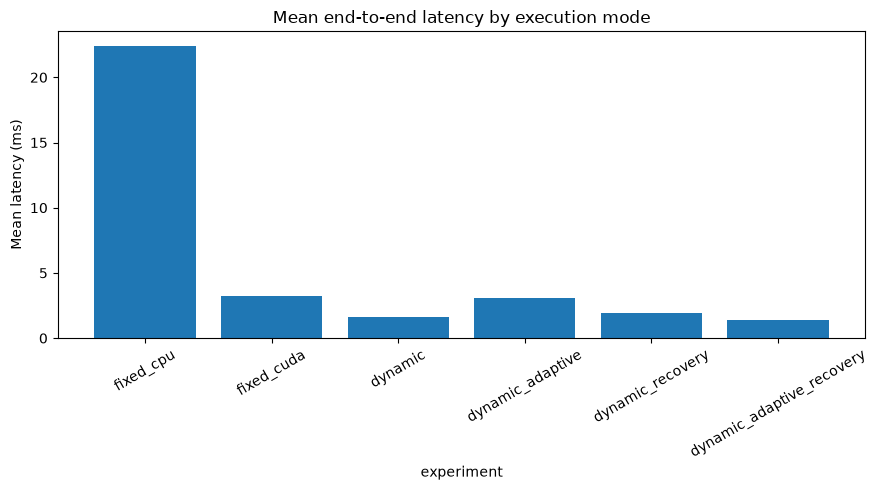

In [13]:
fig = plot_latency_comparison(
    pooled_summary,
    metric="mean_ms",
    title="Mean end-to-end latency by execution mode",
)
fig.show()

/tmp/ipykernel_114139/1431123882.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


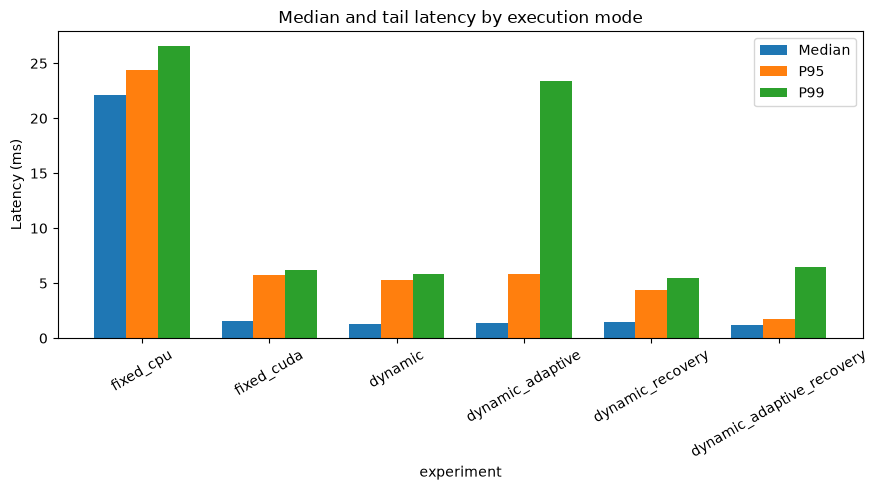

In [14]:
fig = plot_tail_latency(
    pooled_summary,
    title="Median and tail latency by execution mode",
)
fig.show()

### Latency distributions

The first boxplot shows all conditions. The second is the **FlexOn-only** view; this avoids visually compressing the 1–7 ms distributions because the CPU baseline is much slower.


In [15]:
samples = latency_samples_dataframe(records)
fig = plot_latency_distribution(
    samples,
    exclude_groups=[],
    title="End-to-end latency distribution — all configurations",
)
fig.show()


ValueError: no samples remain after excluding groups

### Percentile view

Percentiles are retained because mean latency alone can hide rare tail spikes. The focused view makes the P90/P95/P99 behavior of the FlexOn configurations easier to inspect.


/tmp/ipykernel_114139/1807660246.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


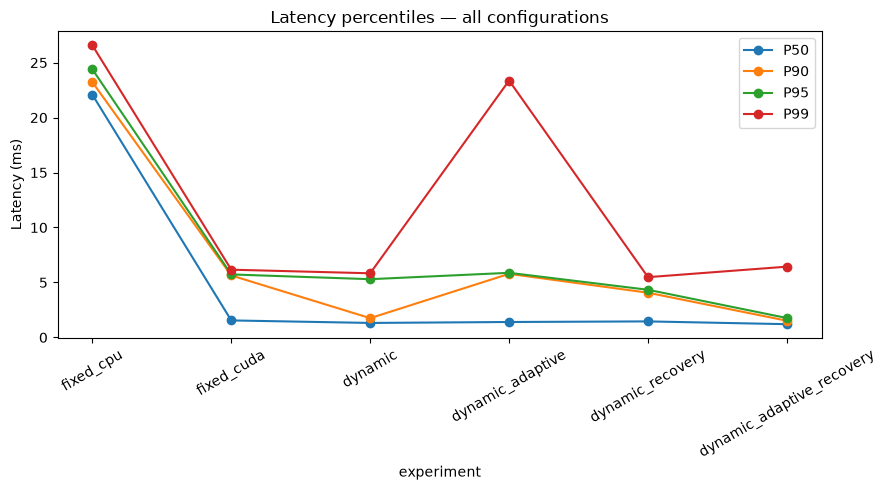

In [16]:
fig = plot_latency_percentiles(
    pooled_summary,
    title="Latency percentiles — all configurations",
)
fig.show()


### Runtime-path diagnostics

These plots are **diagnostics, not latency metrics**. They verify that the intended FlexOn mechanisms were exercised. Segment execution counts are normalized as executions per measured run; adaptive level changes are shown separately.


/tmp/ipykernel_114139/23604407.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/tmp/ipykernel_114139/23604407.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


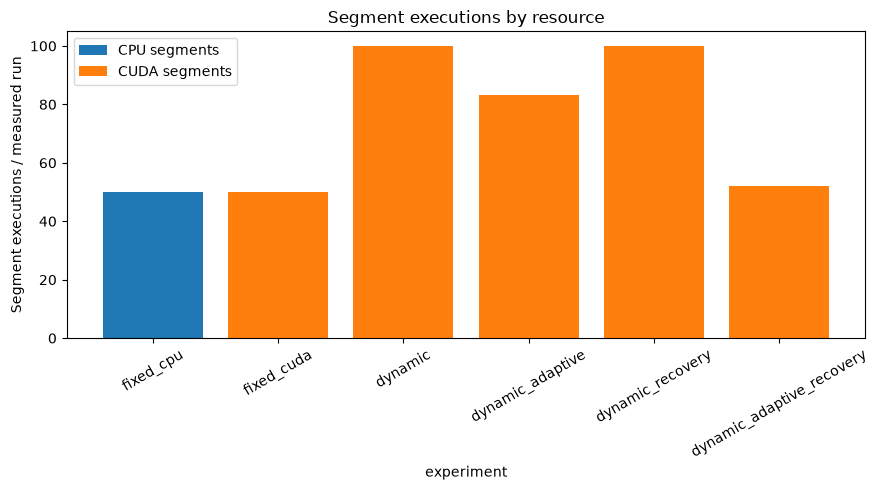

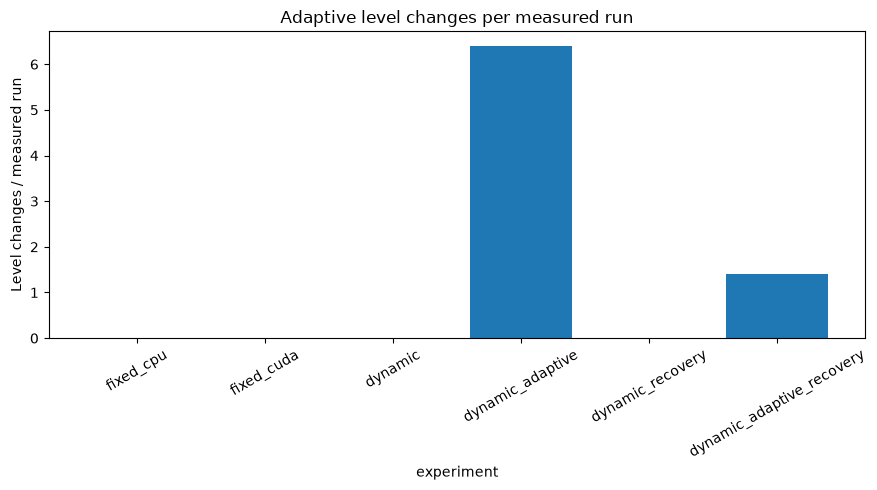

In [17]:
fig = plot_resource_execution_breakdown(
    diagnostics_df,
    title="Segment executions by resource",
)
fig.show()

fig = plot_level_changes(
    diagnostics_df,
    title="Adaptive level changes per measured run",
)
fig.show()

### Diagnostic interpretation

- `total_segment_executions` depends on the segmentation level, so it should not be expected to equal the number of measured iterations.
- `avg_segments_per_iteration` makes different segmentation granularities directly comparable.
- `adaptive_decisions` counts scheduler decisions; `level_changes` counts decisions that actually changed the selected level.
- Recovery counts can legitimately be zero in a no-contention environment because recovery is conditional rather than unconditional.
- Large but rare latency samples should be retained unless there is evidence of an instrumentation error.


## Persist experiment results

The raw measured samples, repetition-level summary, pooled summary, and runtime-path diagnostics are saved so the benchmark does not need to be rerun just to regenerate figures.


In [18]:
samples.to_csv(RESULTS_DIR / ENVIRONMENT_LABEL / "latency_samples.csv", index=False)
summary.to_csv(RESULTS_DIR / ENVIRONMENT_LABEL / "repetition_summary.csv", index=False)
pooled_summary.to_csv(RESULTS_DIR / ENVIRONMENT_LABEL / "pooled_summary.csv", index=False)
diagnostics_df.to_csv(RESULTS_DIR / ENVIRONMENT_LABEL / "diagnostics.csv", index=False)

print("Saved results under:", RESULTS_DIR / ENVIRONMENT_LABEL)


Saved results under: /home/aditya/Coding_23CSB0B30/Personal-Projects/FlexOn/results/no_contention


## Experimental interpretation checklist

Before using the results in the report/presentation, verify:

- all six cases completed every repetition;
- warmup iterations were excluded consistently;
- fixed CPU and fixed CUDA use level 0 as the monolithic baselines;
- dynamic mode makes the expected resource decisions;
- adaptive modes emit level decisions and exhibit level changes when conditions warrant them;
- recovery modes record recovery attempts and winners when recovery is triggered;
- the same experiment notebook is used for idle and contention environments;
- contention configuration (kind/intensity) is recorded separately for each benchmark batch;
- rare latency outliers are retained and investigated rather than silently removed.
